In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as npv

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size: ", len(test_dataset))

Train size: 60000
Test size:  10000


In [3]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 120, kernel_size=5),
            nn.Tanh()
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = LeNet5().to(device)
print(model)
print("Device:", device)

LeNet5(
  (conv_layers): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=84, bias=True)
    (2): Tanh()
    (3): Linear(in_features=84, out_features=10, bias=True)
  )
)
Device: cpu


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
EPOCHS = 10
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_losses.append(val_loss / len(test_loader))
    val_accs.append(val_correct / val_total)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

Epoch 01/10 | Train Loss: 0.2566 | Train Acc: 0.9266 | Val Loss: 0.0852 | Val Acc: 0.9744
Epoch 02/10 | Train Loss: 0.0803 | Train Acc: 0.9746 | Val Loss: 0.0627 | Val Acc: 0.9800
Epoch 03/10 | Train Loss: 0.0548 | Train Acc: 0.9830 | Val Loss: 0.0520 | Val Acc: 0.9842
Epoch 04/10 | Train Loss: 0.0428 | Train Acc: 0.9865 | Val Loss: 0.0516 | Val Acc: 0.9840
Epoch 05/10 | Train Loss: 0.0355 | Train Acc: 0.9889 | Val Loss: 0.0473 | Val Acc: 0.9844
Epoch 06/10 | Train Loss: 0.0300 | Train Acc: 0.9904 | Val Loss: 0.0528 | Val Acc: 0.9834
Epoch 07/10 | Train Loss: 0.0246 | Train Acc: 0.9919 | Val Loss: 0.0462 | Val Acc: 0.9864
Epoch 08/10 | Train Loss: 0.0218 | Train Acc: 0.9929 | Val Loss: 0.0461 | Val Acc: 0.9865
Epoch 09/10 | Train Loss: 0.0194 | Train Acc: 0.9936 | Val Loss: 0.0462 | Val Acc: 0.9865
Epoch 10/10 | Train Loss: 0.0167 | Train Acc: 0.9944 | Val Loss: 0.0498 | Val Acc: 0.9844


In [6]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, predicted = model(images).max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

print(f"Test Accuracy: {correct / total * 100:.2f}%")

Test Accuracy: 98.44%


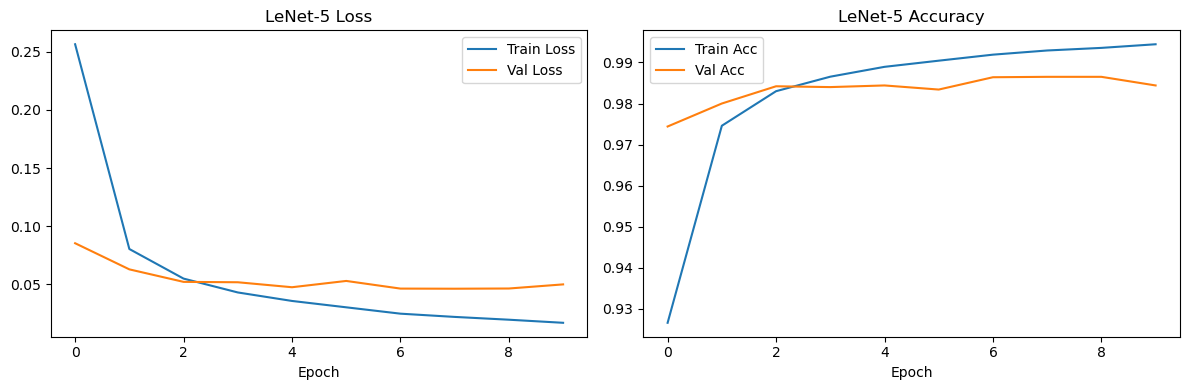

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.title("LeNet-5 Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs,   label="Val Acc")
plt.title("LeNet-5 Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

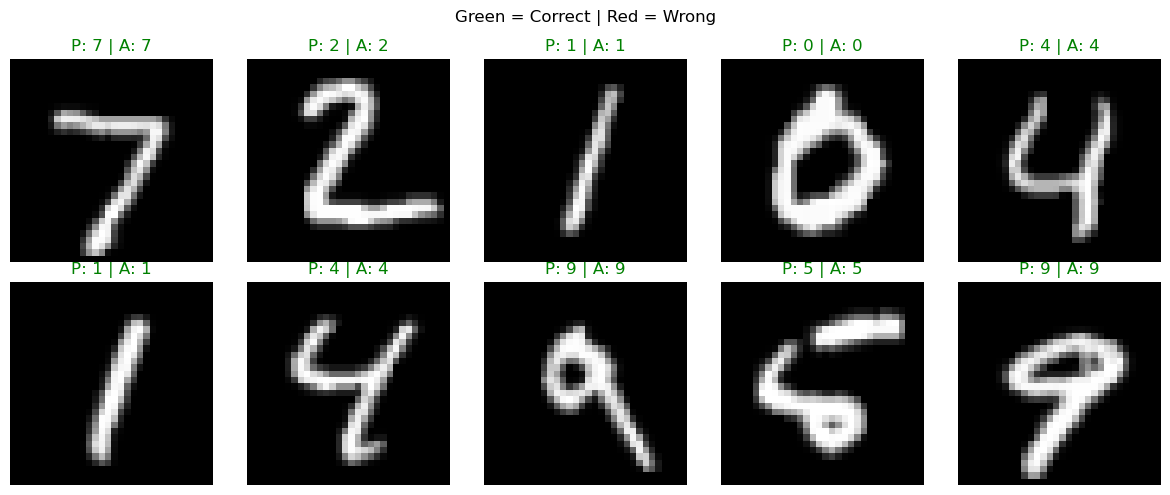

In [8]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    _, predicted = model(images).max(1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu().squeeze().numpy() * 0.5 + 0.5
    ax.imshow(img, cmap="gray")
    color = "green" if predicted[i] == labels[i] else "red"
    ax.set_title(f"P: {predicted[i].item()} | A: {labels[i].item()}", color=color)
    ax.axis("off")
plt.suptitle("Green = Correct | Red = Wrong")
plt.tight_layout()
plt.show()